### Question

Design and implement a fully connected Artificial Neural Network from scratch (without using deep learning libraries like TensorFlow/PyTorch for the core forward/backward pass) to classify synthetic texture patterns.
The dataset has 10,000 samples, each with 600 features (representing a flattened 20×30 pseudo-image), belonging to 5 distinct texture classes.

(a)Implement:
Forward propagation
Backpropagation
Gradient descent optimization manually using NumPy

(b)Experiment with different activation functions:
ReLU
Sigmoid
Tanh
and two hidden layer configurations.

(c)Plot convergence behavior for different learning rates:
0.001
0.01
0.05
0.1
0.5
and for different number of epochs.


In [57]:
# =========================================================
# Fully Connected Artificial Neural Network using NumPy
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)

In [59]:
# =========================================================
# Dataset
# =========================================================

m = 10000          # number of samples
dx = 600           # input features
da1 = 20           # hidden layer 1 neurons
da2 = 20           # hidden layer 2 neurons
c = 5              # output classes


In [60]:
# Synthetic input data
x = np.random.randn(m, dx)

In [61]:
# Random labels from 0 to 4
y_labels = np.random.randint(0, c, size=m)

In [62]:
# One-hot encoding
y = np.zeros((m, c))
y[np.arange(m), y_labels] = 1

In [63]:
# =========================================================
# Train-Test Split
# =========================================================

split = int(0.8 * m)

X_train = x[:split]
Y_train = y[:split]

X_test = x[split:]
Y_test = y[split:]

# Transpose
X_T = X_train.T
Y_T = Y_train.T


In [64]:
# =========================================================
# Activation Functions
# =========================================================

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z) ** 2

In [65]:
# =========================================================
# Softmax Function
# =========================================================

def softmax(z):

    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))

    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

In [66]:
# =========================================================
# Cross Entropy Loss
# =========================================================

def cross_entropy(y_true, y_pred):

    return -np.sum(y_true * np.log(y_pred + 1e-9)) / y_true.shape[1]

In [67]:
# =========================================================
# Neural Network Training Function
# =========================================================

def train_network(activation_name='relu',
                  hidden1=20,
                  hidden2=20,
                  lr=0.001,
                  epochs=50):
      # -----------------------------------------------------
    # Initialize weights and biases
    # -----------------------------------------------------

    w1 = np.random.randn(hidden1, dx) * 0.01
    b1 = np.zeros((hidden1, 1))

    w2 = np.random.randn(hidden2, hidden1) * 0.01
    b2 = np.zeros((hidden2, 1))

    w3 = np.random.randn(c, hidden2) * 0.01
    b3 = np.zeros((c, 1))
    # -----------------------------------------------------
    # Select activation function
    # -----------------------------------------------------

    if activation_name == 'relu':

        activation = relu
        activation_derivative = relu_derivative

    elif activation_name == 'sigmoid':

        activation = sigmoid
        activation_derivative = sigmoid_derivative

    else:

        activation = tanh
        activation_derivative = tanh_derivative
        # -----------------------------------------------------
    # Store loss values
    # -----------------------------------------------------

    losses = []

    # -----------------------------------------------------
    # Training Loop
    # -----------------------------------------------------

    for i in range(epochs):

        # =================================================
        # FORWARD PROPAGATION
        # =================================================

        z1 = np.dot(w1, X_T) + b1
        a1 = activation(z1)

        z2 = np.dot(w2, a1) + b2
        a2 = activation(z2)

        z3 = np.dot(w3, a2) + b3
        y_hat = softmax(z3)

        # =================================================
        # LOSS
        # =================================================

        loss = cross_entropy(Y_T, y_hat)

        losses.append(loss)

        if i % 10 == 0:
            print("Epoch:", i,
                  " Activation:", activation_name,
                  " Loss:", loss)
        # =================================================
        # BACKPROPAGATION
        # =================================================

        # Output layer
        dz3 = y_hat - Y_T

        dw3 = (1 / X_train.shape[0]) * np.dot(dz3, a2.T)
        db3 = (1 / X_train.shape[0]) * np.sum(dz3,
                                              axis=1,
                                              keepdims=True)
        
        # Hidden layer 2
        da2_grad = np.dot(w3.T, dz3)

        dz2 = da2_grad * activation_derivative(z2)

        dw2 = (1 / X_train.shape[0]) * np.dot(dz2, a1.T)
        db2 = (1 / X_train.shape[0]) * np.sum(dz2,
                                              axis=1,
                                              keepdims=True)

        # Hidden layer 1
        da1_grad = np.dot(w2.T, dz2)

        dz1 = da1_grad * activation_derivative(z1)

        dw1 = (1 / X_train.shape[0]) * np.dot(dz1, X_T.T)
        db1 = (1 / X_train.shape[0]) * np.sum(dz1,
                                              axis=1,
                                              keepdims=True)
        # =================================================
        # GRADIENT DESCENT UPDATE
        # =================================================

        w1 = w1 - lr * dw1
        b1 = b1 - lr * db1

        w2 = w2 - lr * dw2
        b2 = b2 - lr * db2

        w3 = w3 - lr * dw3
        b3 = b3 - lr * db3

        # =====================================================
    # TEST ACCURACY
    # =====================================================

    X_test_T = X_test.T

    z1 = np.dot(w1, X_test_T) + b1
    a1 = activation(z1)

    z2 = np.dot(w2, a1) + b2
    a2 = activation(z2)

    z3 = np.dot(w3, a2) + b3

    y_pred = softmax(z3)

    predictions = np.argmax(y_pred, axis=0)

    true_labels = np.argmax(Y_test.T, axis=0)

    accuracy = np.mean(predictions == true_labels)

    print("\nAccuracy:", accuracy)

    return losses

  

In [68]:

# =========================================================
# (a) ANN using NumPy
# =========================================================

print("\n==============================")
print("PART (a)")
print("==============================")

losses_relu = train_network(
    activation_name='relu',
    hidden1=20,
    hidden2=20,
    lr=0.001,
    epochs=50
)


PART (a)
Epoch: 0  Activation: relu  Loss: 1.6094390451069185
Epoch: 10  Activation: relu  Loss: 1.609438434453379
Epoch: 20  Activation: relu  Loss: 1.6094378262345312
Epoch: 30  Activation: relu  Loss: 1.609437220444772
Epoch: 40  Activation: relu  Loss: 1.6094366170604657

Accuracy: 0.1955


In [69]:
# =========================================================
# (b) Different Activation Functions and Hidden Layers
# =========================================================

print("\n==============================")
print("PART (b)")
print("==============================")

activations = ['relu', 'sigmoid', 'tanh']

hidden_configs = [
    (20, 20),
    (50, 30)
]

for act in activations:

    for h1, h2 in hidden_configs:

        print("\nActivation:", act,
              " Hidden Layers:", h1, h2)

        train_network(
            activation_name=act,
            hidden1=h1,
            hidden2=h2,
            lr=0.001,
            epochs=30
        )



PART (b)

Activation: relu  Hidden Layers: 20 20
Epoch: 0  Activation: relu  Loss: 1.609440106564126
Epoch: 10  Activation: relu  Loss: 1.6094394843720266
Epoch: 20  Activation: relu  Loss: 1.6094388646637736

Accuracy: 0.2095

Activation: relu  Hidden Layers: 50 30
Epoch: 0  Activation: relu  Loss: 1.6094404781388107
Epoch: 10  Activation: relu  Loss: 1.6094398513899681
Epoch: 20  Activation: relu  Loss: 1.609439227127719

Accuracy: 0.199

Activation: sigmoid  Hidden Layers: 20 20
Epoch: 0  Activation: sigmoid  Loss: 1.6095606922839099
Epoch: 10  Activation: sigmoid  Loss: 1.6095541256488382
Epoch: 20  Activation: sigmoid  Loss: 1.6095477139875403

Accuracy: 0.1965

Activation: sigmoid  Hidden Layers: 50 30
Epoch: 0  Activation: sigmoid  Loss: 1.609682238661007
Epoch: 10  Activation: sigmoid  Loss: 1.6096690060366932
Epoch: 20  Activation: sigmoid  Loss: 1.6096562113552084

Accuracy: 0.1965

Activation: tanh  Hidden Layers: 20 20
Epoch: 0  Activation: tanh  Loss: 1.6094369969199271
E


PART (c)
Epoch: 0  Activation: relu  Loss: 1.6094363541005678
Epoch: 10  Activation: relu  Loss: 1.6094357368794219
Epoch: 20  Activation: relu  Loss: 1.6094351221100687

Accuracy: 0.2055
Epoch: 0  Activation: relu  Loss: 1.609436999999435
Epoch: 10  Activation: relu  Loss: 1.6094309695358493
Epoch: 20  Activation: relu  Loss: 1.6094251749211932

Accuracy: 0.189
Epoch: 0  Activation: relu  Loss: 1.6094357537916857
Epoch: 10  Activation: relu  Loss: 1.6094075200071416
Epoch: 20  Activation: relu  Loss: 1.6093844060301568

Accuracy: 0.1925
Epoch: 0  Activation: relu  Loss: 1.609437252388097
Epoch: 10  Activation: relu  Loss: 1.60938551336057
Epoch: 20  Activation: relu  Loss: 1.609350915060892

Accuracy: 0.193
Epoch: 0  Activation: relu  Loss: 1.6094384760035296
Epoch: 10  Activation: relu  Loss: 1.6093023785144478
Epoch: 20  Activation: relu  Loss: 1.6092850666163132

Accuracy: 0.193


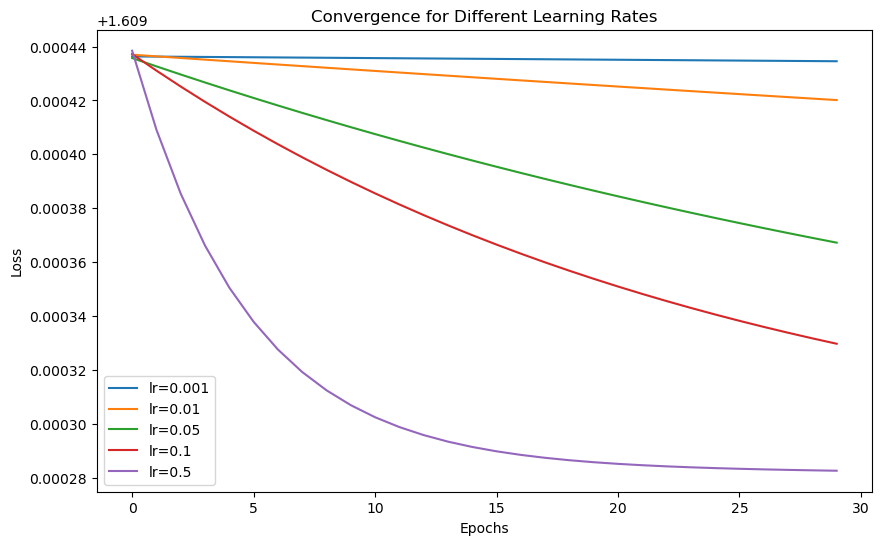

In [70]:
# =========================================================
# (c) Plot Convergence for Different Learning Rates
# =========================================================

print("\n==============================")
print("PART (c)")
print("==============================")

learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]

plt.figure(figsize=(10, 6))

for lr in learning_rates:

    losses = train_network(
        activation_name='relu',
        hidden1=20,
        hidden2=20,
        lr=lr,
        epochs=30
    )

    plt.plot(losses, label="lr=" + str(lr))

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence for Different Learning Rates")
plt.legend()
plt.show()

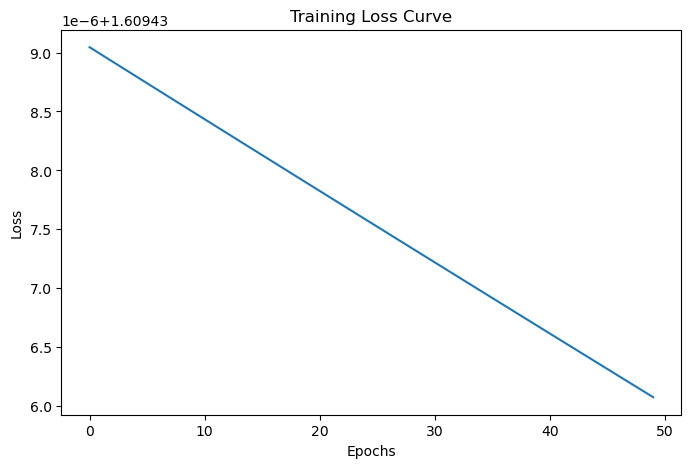

In [71]:
# =========================================================
# Plot Loss Curve
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(losses_relu)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.show()